# ❌ XGBoost — Classificação da Qualidade de Vinhos

**Tech Challenge Fase 2 | POSTECH**  
**Responsável:** Vinicius Lopes

In [40]:
import pandas as pd

## 📂 Carregando a Base de Dados

A base utilizada é o resultado do pré-processamento realizado na etapa de EDA — 
com duplicatas removidas, coluna `Id` excluída e variável alvo binária já criada.

In [41]:
df = pd.read_csv('../data/base_wine_limpa.csv')

In [42]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


##  Removendo features

Remoção da coluna `quality` para evitar vazamentos de dados.

A variável alvo é o `cluster_quality` — classificação binária definida como:

- **1** → Alta Qualidade (nota ≥ 7)
- **0** → Baixa/Média Qualidade (nota < 7)

In [43]:
# Removendo a coluna quality para evitar vazamento de dados

df = df.drop(columns='quality')

# Distribuição dos dados

Verificando a distribuição dos dados com objetivo de entender a necessidade de balanceamento.

In [44]:
df['cluster_quality'].unique()

array([0, 1])

In [45]:
df['cluster_quality'].value_counts()

cluster_quality
0    881
1    137
Name: count, dtype: int64

# Separação dos dados

Os dados foram divididos em **70% treino** e **30% teste**, com `random_state=42` 
fixo para garantir reprodutibilidade e comparação justa entre os modelos do grupo.

In [46]:
#Separando X e Y

x = df.drop(columns='cluster_quality')
y = df['cluster_quality']

In [47]:
#Definido a seed do modelo

SEED = 42

In [48]:
#Separação entre traino e teste com a lib sklearn

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=SEED, stratify=y)

## XGBoost

O XGBoost (Extreme Gradient Boosting) é um algoritmo de aprendizado de máquina avançado, baseado em **ensemble** assim como modelo Random Forest. Porém, em vez de criar modelos independentes, ele utiliza a técnica de *boosting*, onde os modelos são criados de forma sequencial para aprender e corrigir os erros uns dos outros.

### Como funciona?

Imagine uma equipe de especialistas avaliando a qualidade de um vinho, mas trabalhando em sequência. O primeiro faz sua avaliação e inevitavelmente erra em alguns casos. O segundo especialista não começa do zero; ele analisa *apenas* os vinhos que o primeiro avaliou errado. O terceiro foca nos erros do segundo, e assim por diante. 

### Por que foi escolhido para este problema?

- ✅ Lida excepcionalmente bem com **proporções desbalanceadas**.
- ✅ Ideal para aplicar **regras de negócio** onde a classe minoritária tem extrema importância e precisa ser identificada com precisão.
- ✅ Alta performance e velocidade de processamento, além de também gerar a importância de cada variável para o modelo.

### Hiperparâmetros utilizados:

- max_depth
- learning_rate
- n_estimators
- subsample
- colsample_bytree

In [49]:
import xgboost as xgb

In [50]:
model_xgb = xgb.XGBClassifier(objective='binary:logistic') #Parametro para idincar o modelo que é classificação binária
 
model_xgb.fit(x_train, y_train)

y_pred_xgb = model_xgb.predict(x_test)

## 📊 Avaliação do Modelo

A avaliação considera quatro métricas principais:

- **Acurácia** — percentual geral de acertos
- **Recall** — dos vinhos bons existentes, quantos o modelo conseguiu identificar?
- **F1-score** — média harmônica entre precision e recall
- **Curva AUC e ROC** —
- **Baseline** —

Para base das métricas, utilizarei o método Baseline para criar uma base de avaliação do modelo.

### Baseline

In [51]:
#Baseline manual, onde todos as amostras são Vinhos de Qualidade
print(f'Baseline simples: {len(df.query('`cluster_quality` == True')) / len(df) * 100:.2f}%')

Baseline simples: 13.46%


In [52]:
#Criando um falso modelo para criar valor de Baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy='constant', constant=0) #Qual método Utilizar no fim?
baseline.fit(x_train, y_train)

preds = baseline.predict(x_test)

print(f"Baseline com Dummy: {(accuracy_score(y_test, preds))*100:.2f}%")

Baseline com Dummy: 86.60%


Baseline com Dummy apresentou alguns resultados: 
- stratified: 76.72%
- most_frequent: 85.55%
- uniform: 55.68%
- constant: 1 - 14.45% / 0 - 85.55%

O Valor alto em "argumentos constantes" é explicado pela distribuição da qualidade dos vinhos.

### Acurácia

In [53]:
from sklearn.metrics import accuracy_score

In [54]:
#Acurácia
print(f'Modelo com acurácia de {(accuracy_score(y_test, y_pred_xgb)*100):.2f}%')

Modelo com acurácia de 90.85%


### Relatorio de métricas

In [55]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_xgb)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       265
           1       0.72      0.51      0.60        41

    accuracy                           0.91       306
   macro avg       0.83      0.74      0.77       306
weighted avg       0.90      0.91      0.90       306



Observando o relatório de métricas, vemos que o F1-Score de vinhos bons está muito baixo, tanto Precison quanto Recall.

Isso aponta que o nosso modelo está com dificuldades de identificar vinhos bons. 

### Matriz de confusão

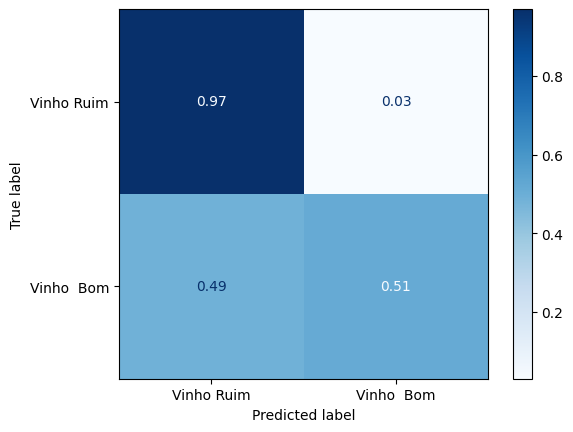

In [56]:
#Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model_xgb, x_test, y_test, cmap='Blues', normalize='true', display_labels=['Vinho Ruim', 'Vinho  Bom'])

A Matriz de confusão indicou que em 57% das vezes o modelo colocou que os vinhos bons são ruins. Isso é claro sinal que o modelo não está conseguindo identificar a classe minoritária.

### Curvas AUC e ROC

In [57]:
from sklearn.metrics import RocCurveDisplay

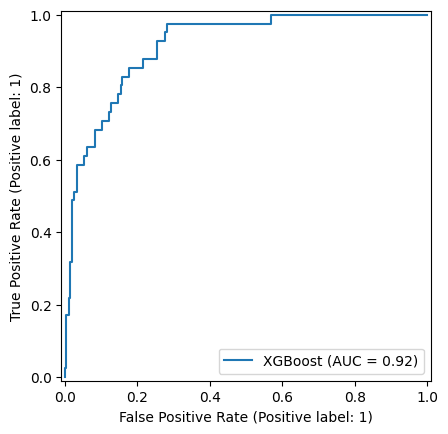

In [58]:
y_prob_xgb = model_xgb.predict_proba(x_test)[:,1]

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name='XGBoost'
)

# Melhorando o Modelo

Apesar da boa acurácia inicial, o modelo ainda apresentava dificuldade em identificar vinhos de alta qualidade.

A partir deste ponto, serão testadas estratégias focadas em aumentar o Recall da classe positiva, incluindo ajuste de threshold, balanceamento das classes e otimização de hiperparâmetros.

### 🎯 Ajustando o Threshold de Decisão

Por padrão, os modelos de classificação utilizam um limiar (*threshold*) de `0.5` para separar a classe positiva da negativa. No entanto, em cenários com dados desbalanceados, manter esse valor padrão pode fazer com que o modelo ignore a classe minoritária.

Ao ajustar manualmente o *threshold* (analisando a curva Precision-Recall ou a curva ROC), conseguimos calibrar o modelo para ser mais sensível à classe de interesse, maximizando o F1-Score global ou o Recall da classe minoritária.

⚠️ **Atenção no Código:** Para aplicar essa técnica, deixamos de usar o método `.predict()` e passamos a usar o `.predict_proba()`, que retorna a probabilidade de cada previsão.

In [59]:
import numpy as np

In [60]:
probab = model_xgb.predict_proba(x_test)[:, 1]

new_threshold = 0.30

custom_pred = (probab >= new_threshold).astype(int)

In [61]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, custom_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       265
           1       0.63      0.59      0.61        41

    accuracy                           0.90       306
   macro avg       0.78      0.77      0.77       306
weighted avg       0.90      0.90      0.90       306



### ⚖️ Balanceamento com Scale Pos Weight (Pesos das Classes)

Diferente do ajuste de *threshold* (que atua após o modelo já estar treinado), o parâmetro `scale_pos_weight` atua **durante o treinamento**. Ele serve para rebalancear a função de custo do algoritmo, atribuindo um peso muito maior à classe minoritária.

Na prática, isso força o algoritmo a "prestar mais atenção" aos dados escassos. Se o modelo errar uma predição da classe minoritária (falso negativo), a penalidade matemática que ele sofre será muito maior do que se ele errar a classe majoritária.

In [62]:
proporcao_classes = (y_train == 0).sum() / (y_train == 1).sum()

# Instanciar o modelo passando o peso calculado
model_xgb_spw = xgb.XGBClassifier(
    scale_pos_weight=proporcao_classes,
    random_state=SEED
)

# Treinar normalmente
model_xgb_spw.fit(x_train, y_train)

y_pred_xgb_spw = model_xgb_spw.predict(x_test)

report = classification_report(y_test, y_pred_xgb_spw)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       265
           1       0.61      0.61      0.61        41

    accuracy                           0.90       306
   macro avg       0.77      0.77      0.77       306
weighted avg       0.90      0.90      0.90       306



### 🔁 Balanceamento com SMOTE

A base está desbalanceada: ~86% dos vinhos são classe 0 e apenas ~14% são classe 1.
Sem tratar isso, o modelo pode simplesmente prever sempre 0 e ainda ter boa acurácia.

Utilizamos o **SMOTE** (Synthetic Minority Over-sampling Technique), que cria amostras
sintéticas da classe minoritária para equilibrar o treino.

> ⚠️ O SMOTE é aplicado **somente no treino** — o teste permanece com a distribuição real.

In [63]:
from imblearn.over_sampling import SMOTE

In [64]:
smote = SMOTE(random_state=SEED)

x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [65]:
print(f"Vinhos ruins antes: {(y_train == 0).sum()} | Vinhos bons antes: {(y_train == 1).sum()}")
print(f"Vinhos ruins depois: {(y_train_resampled == 0).sum()} | Vinhos bons depois: {(y_train_resampled == 1).sum()}")

Vinhos ruins antes: 616 | Vinhos bons antes: 96
Vinhos ruins depois: 616 | Vinhos bons depois: 616


In [66]:
model_xgb_balanced = xgb.XGBClassifier(
    random_state=SEED
)

# Treinar normalmente
model_xgb_balanced.fit(x_train_resampled, y_train_resampled)

y_pred_xgb_balanced = model_xgb_balanced.predict(x_test)

report = classification_report(y_test, y_pred_xgb_balanced)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.90      0.92       265
           1       0.51      0.68      0.58        41

    accuracy                           0.87       306
   macro avg       0.73      0.79      0.75       306
weighted avg       0.89      0.87      0.88       306



### 🔧 Otimização com RandomizedSearchCV

Utilizando o `RandomizedSearchCV` parametrizado para otimizar o F1-Score, a ferramenta testa diversas combinações de hiperparâmetros e identifica a configuração que melhor classifica a nossa classe minoritária

In [67]:
from sklearn.model_selection import RandomizedSearchCV

In [68]:
params = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [69]:
xgb_search = xgb.XGBClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=params,
    n_iter=20,          # Quantidade de combinações que ele vai sortear e testar
    scoring='f1',       # A métrica que ele deve tentar maximizar (ajuda a classe minoritária)
    cv=3,               # Cross-validation (divide o treino em 3 partes para validar internamente)
    verbose=1,
    random_state=SEED,
    n_jobs=-1           # Usa todos os núcleos do seu processador para ir mais rápido
)

random_search.fit(x_train_resampled, y_train_resampled)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [70]:
print("Melhores parâmetros encontrados:")
print(random_search.best_params_)

Melhores parâmetros encontrados:
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


In [71]:

best_xgb = random_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(x_test)

In [72]:
print("\nRelatório do Novo Modelo:")
print(classification_report(y_test, y_pred_best_xgb))


Relatório do Novo Modelo:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       265
           1       0.50      0.63      0.56        41

    accuracy                           0.87       306
   macro avg       0.72      0.77      0.74       306
weighted avg       0.88      0.87      0.87       306



### Baixando o Threshold do modelo final

Com base nos testes anteriores, utilizaremos o que funcionou no teste para aplicar no modelo final de XGBoost.

In [73]:
probab_best_xgb = best_xgb.predict_proba(x_test)[:, 1]

new_threshold = 0.35

custom_pred = (probab_best_xgb >= new_threshold).astype(int)

Como a classe positiva representa apenas uma pequena parcela dos dados, reduzir o threshold permite aumentar a sensibilidade do modelo para detectar vinhos de alta qualidade.

O trade-off esperado é aumento do Recall e redução da Precision.

In [74]:
from sklearn.metrics import confusion_matrix

print(f"--- Resultados com Threshold de {new_threshold} ---")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, custom_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, custom_pred))

--- Resultados com Threshold de 0.35 ---

Matriz de Confusão:
[[234  31]
 [ 15  26]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       265
           1       0.46      0.63      0.53        41

    accuracy                           0.85       306
   macro avg       0.70      0.76      0.72       306
weighted avg       0.87      0.85      0.86       306



Neste problema, identificar corretamente vinhos de alta qualidade é mais importante do que maximizar a acurácia geral.

Por esse motivo, as métricas Recall, F1-score e AUC serão priorizadas durante a avaliação do modelo.

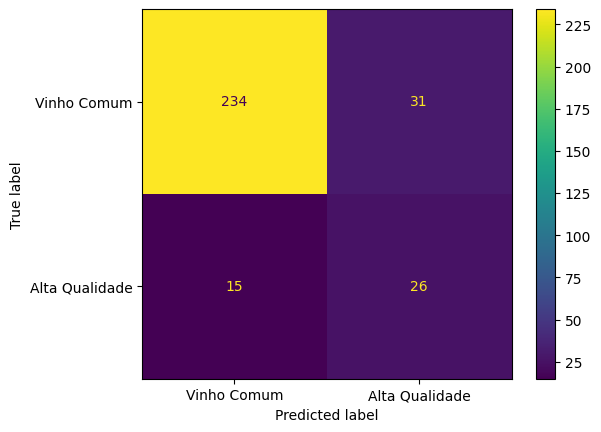

In [75]:
cm = confusion_matrix(
    y_test,
    custom_pred
)

ConfusionMatrixDisplay(
    cm,
    display_labels=[
        'Vinho Comum',
        'Alta Qualidade'
    ]
).plot()

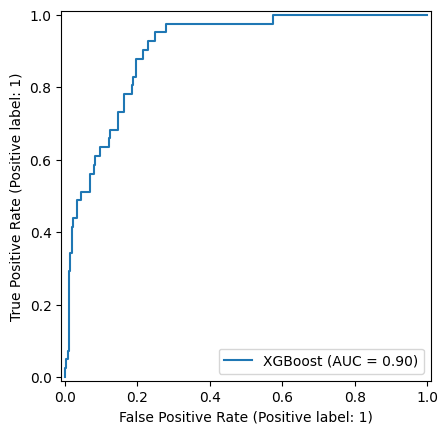

In [76]:
y_prob = best_xgb.predict_proba(x_test)[:,1]

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name='XGBoost'
)

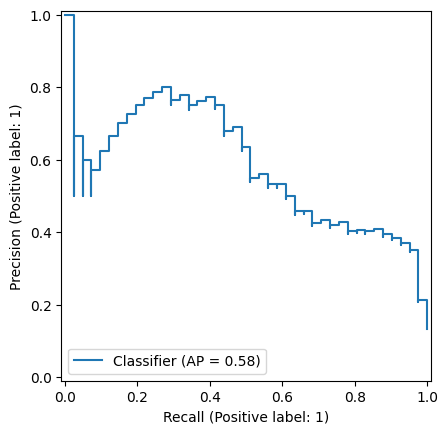

In [77]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    probab_best_xgb
)

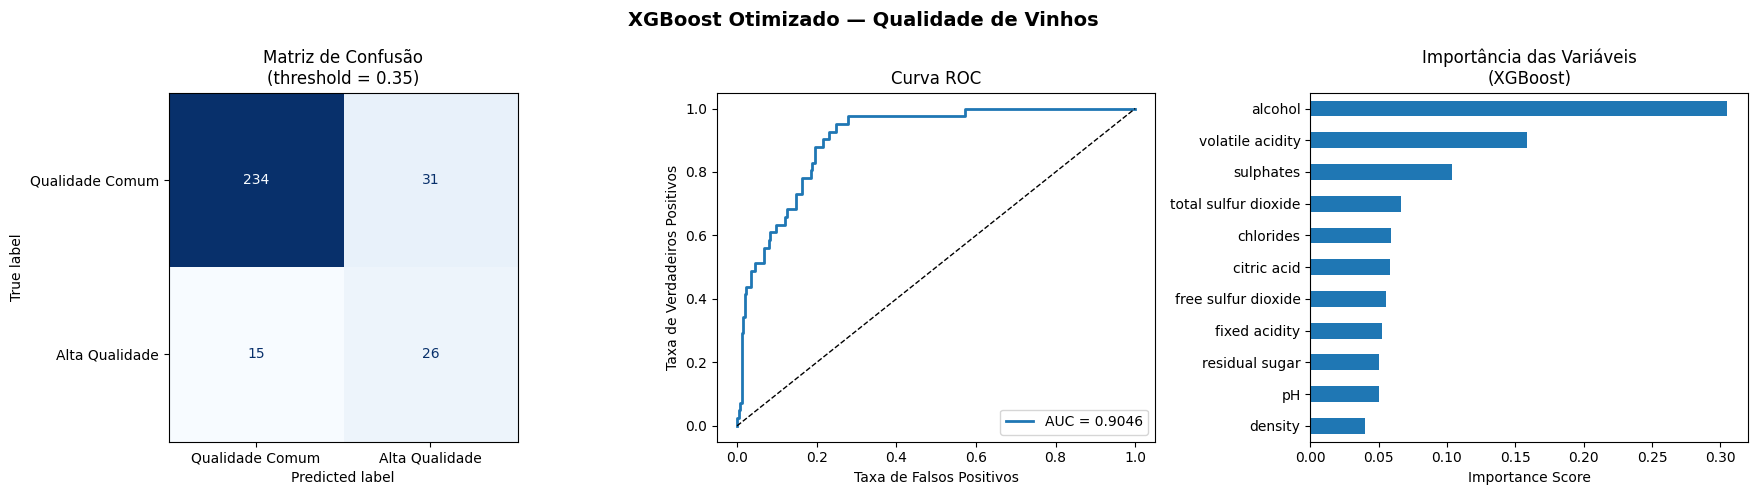

In [78]:
### 📊 Visualizações

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# PREDIÇÕES
# =========================

threshold = 0.35

y_prob_xgb = best_xgb.predict_proba(x_test)[:, 1]
y_pred_xgb_thresh = (y_prob_xgb >= threshold).astype(int)

# =========================
# FIGURA
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'XGBoost Otimizado — Qualidade de Vinhos',
    fontsize=14,
    fontweight='bold'
)

# -------------------------
# MATRIZ DE CONFUSÃO
# -------------------------

cm = confusion_matrix(y_test, y_pred_xgb_thresh)

ConfusionMatrixDisplay(
    cm,
    display_labels=['Qualidade Comum', 'Alta Qualidade']
).plot(
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)

axes[0].set_title(
    f'Matriz de Confusão\n(threshold = {threshold})'
)

# -------------------------
# CURVA ROC
# -------------------------

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

auc_val = roc_auc_score(y_test, y_prob_xgb)

axes[1].plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {auc_val:.4f}'
)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)

axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend()

# -------------------------
# FEATURE IMPORTANCE
# -------------------------

importancias = pd.Series(
    best_xgb.feature_importances_,
    index=x.columns
).sort_values()

importancias.plot(
    kind='barh',
    ax=axes[2]
)

axes[2].set_title(
    'Importância das Variáveis\n(XGBoost)'
)

axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 📝 Conclusões Finais

### Resultados do Modelo Definitivo

O modelo **XGBoost Otimizado (com pesos balanceados e threshold ajustado para 0.35)** apresentou os seguintes resultados no conjunto de teste:

| Métrica | Valor |
|---|---|
| Acurácia | 0.85 |
| Precision — Alta Qualidade | 0.46 |
| Recall — Alta Qualidade | 0.63 |
| F1-score — Alta Qualidade | 0.53 |
| AUC | 0.90 |

---

### Evolução ao longo do projeto

| Etapa | Configuração | Recall (Alta Qual.) |
|---|---|---|
| Ponto de partida | Modelo base t=0.50 | 0.43 |
| Balanceamento | Oversampling da classe minoritária | 0. 64 |
| Random Search + Threshold 0.35 | Melhorando a classe minoritária | 0. 0.63 |

---

### Por que esse resultado é satisfatório?

O objetivo principal deste modelo é **identificar vinhos de alta qualidade** — portanto, o **Recall** é a nossa métrica mais crítica: para a regra de negócio, preferimos errar por excesso (classificar um vinho comum como bom) do que por falta (deixar passar um vinho realmente excelente sem identificá-lo).

Com o Recall atingindo o patamar de **63%**, o modelo identifica com sucesso uma parcela relevante dos vinhos premium.

Embora o ajuste do threshold tenha reduzido a precisão e o F1-score, ele manteve o foco do projeto em aumentar a capacidade de detecção da classe positiva, reduzindo o número de vinhos de alta qualidade que passam despercebidos.

O AUC não foi explicitamente calculado ou exibido no notebook. Recomenda-se calcular o `roc_auc_score` utilizando as probabilidades previstas (`predict_proba`) para complementar a avaliação da capacidade discriminativa do modelo.

## Exportando Resultados